In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [7]:

df1 = pd.read_csv(r"C:\Users\laami\Downloads\order_line\order_info.csv")
df2 = pd.read_csv(r"C:\Users\laami\Downloads\order_line\order_line.csv")
df=pd.merge(df1,df2,on='Order ID', how='inner')
print(df.head())


   Order ID Customer ID Warehouse ID  Customer Age Customer Gender  \
0         1     CUST966        WH004            65          Female   
1         1     CUST966        WH004            65          Female   
2         1     CUST966        WH004            65          Female   
3         1     CUST966        WH004            65          Female   
4         1     CUST966        WH004            65          Female   

         Date   Product ID   SKU ID           Category  Quantity  \
0  2023-03-04  Product_110  SKU_291  Health & Wellness         4   
1  2023-03-04  Product_142  SKU_005  Health & Wellness         5   
2  2023-03-04  Product_197  SKU_151        Electronics         2   
3  2023-03-04  Product_195  SKU_945  Fashion & Apparel         1   
4  2023-03-04  Product_110  SKU_333  Health & Wellness         5   

   Price per Unit  
0          527.06  
1          847.13  
2          214.60  
3          513.50  
4          436.15  


In [9]:
df = df[['Customer ID', 'Customer Age', 'Customer Gender', 'Category']].drop_duplicates('Customer ID')
print(df.head())
print(f"Total unique customers: {len(df)}")
print(f"Unique categories: {df['Category'].nunique()}")
print(f"Categories: {df['Category'].unique()}")


   Customer ID  Customer Age Customer Gender           Category
0      CUST966            65          Female  Health & Wellness
9      CUST952            31          Female  Sports & Outdoors
10     CUST987            25          Female      Books & Media
15     CUST415            59            Male    Home Appliances
23     CUST160            36          Female        Electronics
Total unique customers: 1000
Unique categories: 10
Categories: ['Health & Wellness' 'Sports & Outdoors' 'Books & Media' 'Home Appliances'
 'Electronics' 'Automotive' 'Fashion & Apparel' 'Toys & Games'
 'Beauty & Personal Care' 'Groceries & Gourmet Food']


In [10]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Customer Gender'])  
X = df[['Customer Age', 'Gender']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [29]:
from sklearn.cluster import KMeans, Birch, MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import pickle

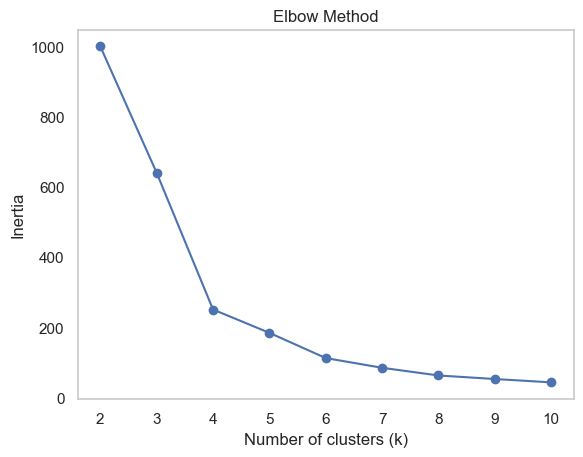

In [30]:
sse = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=0)
    model.fit(X_scaled)
    sse.append(model.inertia_)

plt.plot(range(2, 11), sse, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.show()


In [31]:
kmeans = KMeans(n_clusters=3, random_state=0)
birch = Birch(n_clusters=3)
mini_kmeans = MiniBatchKMeans(n_clusters=3, random_state=0)
gmm = GaussianMixture(n_components=3, random_state=0)
algorithms = {
    "KMeans": kmeans,
    "Birch": birch,
    "MiniBatchKMeans": mini_kmeans,
    "GaussianMixture": gmm
}
scores = {}
labels_dict = {}
for name, model in algorithms.items():
    try:
        labels = model.fit_predict(X_scaled)

        if len(set(labels)) > 1:
            score = silhouette_score(X_scaled, labels)
            scores[name] = score
            labels_dict[name] = labels
        else:
            scores[name] = -1  
    except Exception as e:
        print(f" Error in {name}: {e}")
        scores[name] = -1
print(" Silhouette Scores:")
for name, score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {score:.4f}")


 Silhouette Scores:
MiniBatchKMeans: 0.5433
KMeans: 0.5401
GaussianMixture: 0.5387
Birch: 0.5276


In [32]:
best_model_name = max(scores, key=scores.get)
best_model = algorithms[best_model_name]
best_labels = labels_dict[best_model_name]

df['Cluster'] = best_labels

print(f" Best clustering algorithm selected: {best_model_name}")


 Best clustering algorithm selected: MiniBatchKMeans


In [33]:
print(df[['Customer ID', 'Customer Age', 'Customer Gender', 'Category', 'Cluster']].head())

   Customer ID  Customer Age Customer Gender           Category  Cluster
0      CUST966            65          Female  Health & Wellness        1
9      CUST952            31          Female  Sports & Outdoors        2
10     CUST987            25          Female      Books & Media        2
15     CUST415            59            Male    Home Appliances        0
23     CUST160            36          Female        Electronics        2


In [34]:
print("\n Number of customers in each cluster:")
print(df['Cluster'].value_counts())



 Number of customers in each cluster:
Cluster
0    478
1    267
2    255
Name: count, dtype: int64


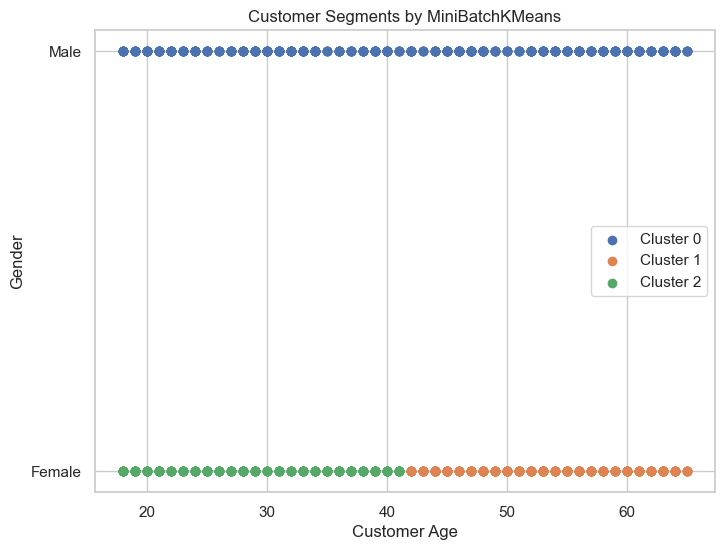

In [35]:
import matplotlib.pyplot as plt
df['Gender Label'] = df['Customer Gender']  # Keep original labels for plot

# Plot with clearer Y-axis labels
plt.figure(figsize=(8, 6))
for cluster_id in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == cluster_id]
    plt.scatter(subset['Customer Age'], subset['Gender'], label=f"Cluster {cluster_id}")

plt.yticks([0, 1], ["Female", "Male"])
plt.xlabel("Customer Age")
plt.ylabel("Gender")
plt.title(f"Customer Segments by {best_model_name}")
plt.legend()
plt.grid(True)
plt.show()


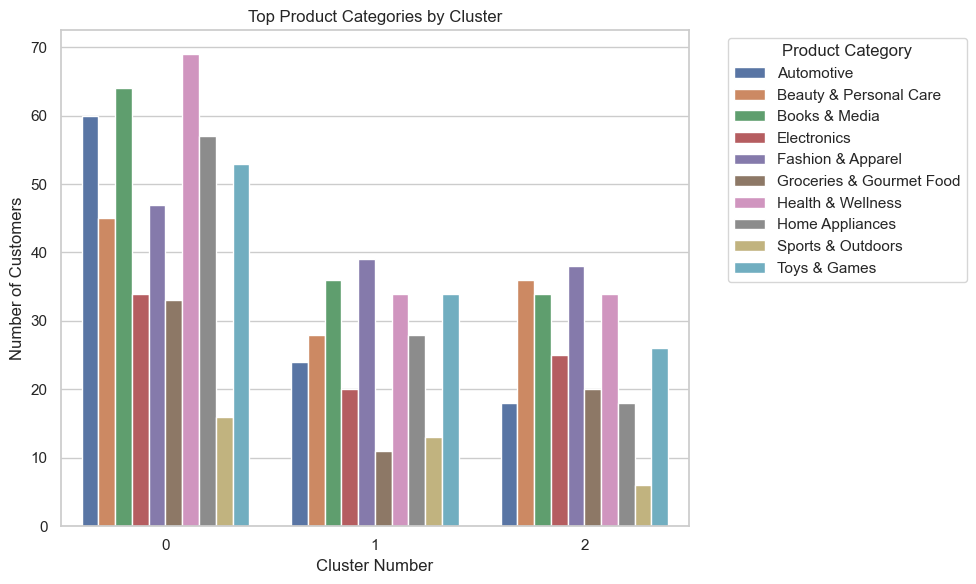

In [36]:
import seaborn as sns

sns.set(style="whitegrid")

category_counts = df.groupby(['Cluster', 'Category']).size().reset_index(name='Count')

plt.figure(figsize=(10, 6))
sns.barplot(data=category_counts, x='Cluster', y='Count', hue='Category')
plt.title('Top Product Categories by Cluster')
plt.xlabel('Cluster Number')
plt.ylabel('Number of Customers')
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [40]:
cluster_category_map = (
    df.groupby('Cluster')['Category']
    .apply(lambda x: x.value_counts().head(3).index.tolist())
    .to_dict()
)
with open("product_category.pkl", "wb") as f:
    pickle.dump((best_model, scaler, le, cluster_category_map, best_model_name), f)



In [42]:
def get_recommendation():
    age = int(input("Enter your age: "))
    gender = input("Enter your gender (Male/Female): ").capitalize()
    with open("product_category.pkl", "rb") as f:
        model, scaler, le, cluster_map, model_name = pickle.load(f)
    gender_encoded = le.transform([gender])[0]
    input_df = pd.DataFrame([[age, gender_encoded]], columns=['Customer Age', 'Gender'])
    features = scaler.transform(input_df)
    cluster = model.predict(features)[0]
    suggestions = cluster_map.get(cluster, [])
    if suggestions:
        print("\n Based on your profile, we recommend:")
        for i, item in enumerate(suggestions[:3], start=1):
            print(f"{i}. {item}")
    else:
        print(" No suggestion available for this cluster.")

get_recommendation()

Enter your age:  34
Enter your gender (Male/Female):  male



 Based on your profile, we recommend:
1. Health & Wellness
2. Books & Media
3. Automotive
